In [1]:
import numpy as np 
import pandas as pd
import os
from readData import *
from baryonFit import HernquistFit, DehnenFit, hernquist_model, KuzminFit, kuzmin_model

import matplotlib.pyplot as plt

# Lists of test Galaxies

In [2]:
disk_and_bulge_galaxies = ["NGC6674", "NGC7331", "NGC2841"]

disk_galaxies = ["NGC6503", "NGC4214", "NGC1705"]

In [3]:
galaxy_list = get_galaxy_ids()
print("Galaxy list:", galaxy_list[:5])

Galaxy list: ['NGC5371', 'UGC05829', 'NGC5005', 'UGCA444', 'NGC1003']


Subset of galaxies to analyze: ['NGC6674', 'NGC6503']


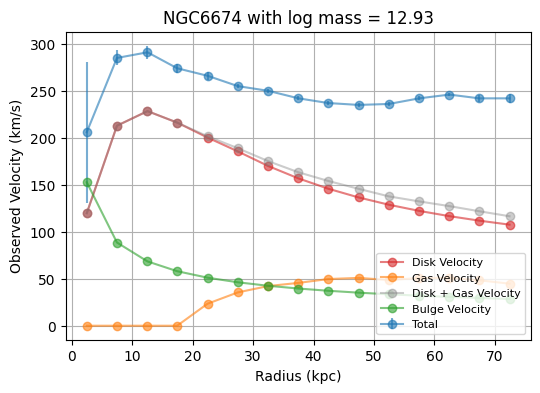

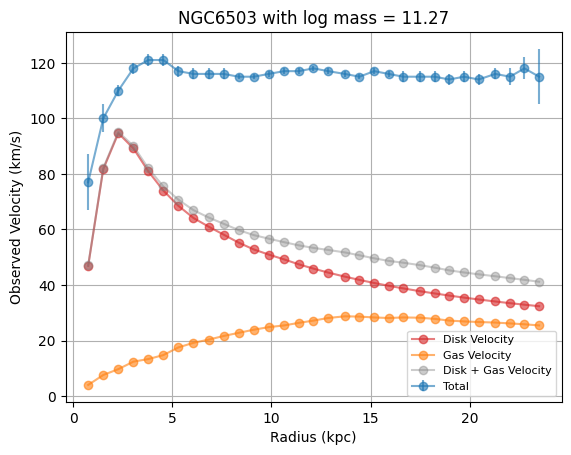

In [4]:
subset = ["NGC6674", "NGC6503"]
print("Subset of galaxies to analyze:", subset)

plt.figure(figsize=(6,4))
for g in subset:
    df, _, _ = get_rc_data(g)
    gamma_d, _ = Gamma_disk(g) 
    gamma_b, _ = Gamma_bulge(g)
    M200, _ = log_M200_weighted_mean(g)
    # total_baryon_rc = np.sqrt(np.sqrt(gamma_d)*df["Vdisk"]**2 + df["Vgas"]**2 + np.sqrt(gamma_b)*df["Vbul"]**2)
    # dm_rc = np.sqrt(df["Vobs"]**2 - total_baryon_rc**2)
    plt.errorbar(df["Rad"], df["Vobs"], yerr=df["errV"], marker='o', linestyle='-', alpha=0.6, color='C0', label='Total')
    plt.plot(df["Rad"], np.sqrt(gamma_d)*df["Vdisk"], marker='o', linestyle='-', alpha=0.6, color='C3', label='Disk Velocity')
    plt.plot(df["Rad"], np.abs(df["Vgas"]), marker='o', linestyle='-', alpha=0.6, color='C1', label='Gas Velocity')
    plt.plot(df["Rad"], np.sqrt(np.sqrt(gamma_d)**2*df["Vdisk"]**2 + df["Vgas"]**2), marker='o', linestyle='-', alpha=0.4, color='grey', label='Disk + Gas Velocity')
    if df["Vbul"].sum() > 0:
        plt.plot(df["Rad"], np.sqrt(gamma_b)*df["Vbul"], marker='o', linestyle='-', alpha=0.6, color='C2', label='Bulge Velocity')
    plt.legend(fontsize=8, loc="lower right")
    plt.title(f'{g} with log mass = {M200:.2f}')
    plt.xlabel('Radius (kpc)')
    plt.ylabel('Observed Velocity (km/s)')
    plt.grid()
    plt.show()
    plt.close()  

# Check the fits

Fitting Hernquist model to NGC6503 with upsilon_d = 0.44, upsilon_b = 0.00
Fitting with lmfit took 0.0131 seconds
Fitted parameters for galaxy NGC6503 using lmfit:
  M_b = 1.16e+10 solar masses
  a   = 2.01 kpc
  chi-squared = 1108.9565
Fitted parameters for NGC6503: M_b = 1.16e+10, a = 2.01


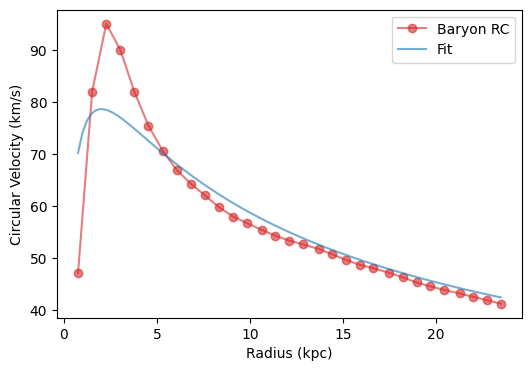

In [5]:
dgbrc = subset[0]
dgrc = subset[1]

galaxy = dgrc

# fit to the disk + gas galaxy 
upsilon_d, _ = Gamma_disk(galaxy)
upsilon_b, _ = Gamma_bulge(galaxy)
print(f"Fitting Hernquist model to {galaxy} with upsilon_d = {upsilon_d:.2f}, upsilon_b = {upsilon_b:.2f}")
fitter = HernquistFit(galaxy, gamma_star=upsilon_d, gamma_bulge=upsilon_b, method='lmfit')

# data 
df, _, _ = get_rc_data(galaxy)

radii = fitter.r_vals
baryon_rc = fitter.vc_disk_gas
Mb = fitter.M_b_fit
a = fitter.a_fit
print(f"Fitted parameters for {galaxy}: M_b = {Mb:.2e}, a = {a:.2f}")
r_list = np.linspace(radii.min(), radii.max(), 100)
vc_fit = hernquist_model(r_list, log_M_b=np.log10(Mb), log_a=np.log10(a))

# plot the results
plt.figure(figsize=(6,4))
plt.plot(radii, baryon_rc, marker='o', linestyle='-', alpha=0.6, color='C3', label='Baryon RC')
plt.plot(r_list, vc_fit, marker='None', linestyle='-', alpha=0.6, color='C0', label='Fit')
plt.xlabel('Radius (kpc)')
plt.ylabel('Circular Velocity (km/s)')
plt.legend()
plt.show()

Fitting Hernquist model to NGC6674 with upsilon_d = 0.95, upsilon_b = 0.79
Fitting with lmfit took 0.0188 seconds
Fitted parameters for galaxy NGC6674 using lmfit:
  M_b = 3.80e+11 solar masses
  a   = 10.02 kpc
  chi-squared = 4387.5384
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0158 seconds
Fitted parameters for galaxy NGC6674 using lmfit:
  M_b = 1.37e+10 solar masses
  a   = 0.01 kpc
  chi-squared = 0.0083


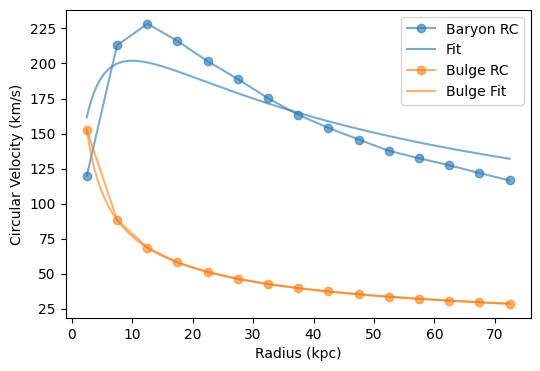

In [11]:
galaxy = dgbrc

# fit to the disk + gas galaxy 
upsilon_d, _ = Gamma_disk(galaxy)
upsilon_b, _ = Gamma_bulge(galaxy)
print(f"Fitting Hernquist model to {galaxy} with upsilon_d = {upsilon_d:.2f}, upsilon_b = {upsilon_b:.2f}")
fitter = HernquistFit(galaxy, gamma_star=upsilon_d, gamma_bulge=upsilon_b, method='lmfit')

# data 
radii = fitter.r_vals
baryon_rc = fitter.vc_disk_gas
bulge_rc = fitter.vc_bulge
r_list = np.geomspace(radii.min(), radii.max(), 1000)

Mb = fitter.M_b_fit
a = fitter.a_fit
vc_fit = hernquist_model(r_list, log_M_b=np.log10(Mb), log_a=np.log10(a))

Mb_bulge = fitter.M_b_fit_bulge
a_bulge = fitter.a_fit_bulge
vc_fit_bulge = hernquist_model(r_list, log_M_b=np.log10(Mb_bulge), log_a=np.log10(a_bulge))

# plot the results
plt.figure(figsize=(6,4))
plt.plot(radii, baryon_rc, marker='o', linestyle='-', alpha=0.6, color='C0', label='Baryon RC')
# plt.plot(radii, fitter.vc(radii, M_b=fitter.M_b_fit, a=fitter.a_fit), marker='o', linestyle='-', alpha=0.6, color='C5', label='Total RC')
plt.plot(r_list, vc_fit, marker='None', linestyle='-', alpha=0.6, color='C0', label='Fit')
plt.plot(radii, bulge_rc, marker='o', linestyle='-', alpha=0.6, color='C1', label='Bulge RC')
plt.plot(r_list, vc_fit_bulge, marker='None', linestyle='-', alpha=0.6, color='C1', label='Bulge Fit')
plt.xlabel('Radius (kpc)')
plt.ylabel('Circular Velocity (km/s)')
plt.legend()
plt.show()

# Fitting with Kuzmin disk

Fitting with lmfit took 0.0111 seconds
Fitted parameters for galaxy NGC6503 using lmfit:
  M_b = 8.25e+09 solar masses
  a   = 1.78 kpc
  chi-squared = 305.8030
Fitted parameters for NGC6503: M_b = 8.25e+09, a = 1.78


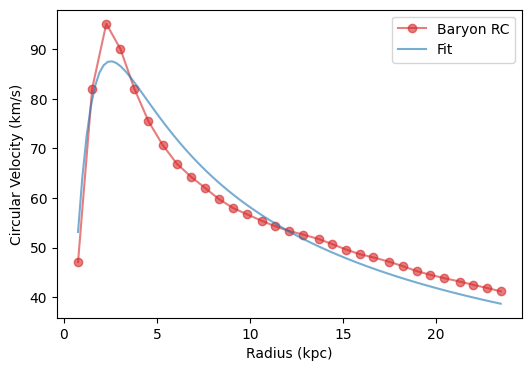

In [9]:
galaxy = dgrc

# fit to the disk + gas galaxy 
upsilon_d, _ = Gamma_disk(galaxy)
upsilon_b, _ = Gamma_bulge(galaxy)
fitter = KuzminFit(galaxy, gamma_star=upsilon_d, gamma_bulge=upsilon_b, method='lmfit')

# data 
df, _, _ = get_rc_data(galaxy)

radii = fitter.r_vals
baryon_rc = fitter.vc_disk_gas
Mb = fitter.M_b_fit
a = fitter.a_fit
print(f"Fitted parameters for {galaxy}: M_b = {Mb:.2e}, a = {a:.2f}")
r_list = np.linspace(radii.min(), radii.max(), 100)
vc_fit = kuzmin_model(r_list, log_M_b=np.log10(Mb), log_a=np.log10(a))

# plot the results
plt.figure(figsize=(6,4))
plt.plot(radii, baryon_rc, marker='o', linestyle='-', alpha=0.6, color='C3', label='Baryon RC')
plt.plot(r_list, vc_fit, marker='None', linestyle='-', alpha=0.6, color='C0', label='Fit')
plt.xlabel('Radius (kpc)')
plt.ylabel('Circular Velocity (km/s)')
plt.legend()
plt.show()

Fitting with lmfit took 0.0132 seconds
Fitted parameters for galaxy NGC6674 using lmfit:
  M_b = 2.44e+11 solar masses
  a   = 7.61 kpc
  chi-squared = 142.6239
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0092 seconds
Fitted parameters for galaxy NGC6674 using lmfit:
  M_b = 1.37e+10 solar masses
  a   = 0.01 kpc
  chi-squared = 0.0083


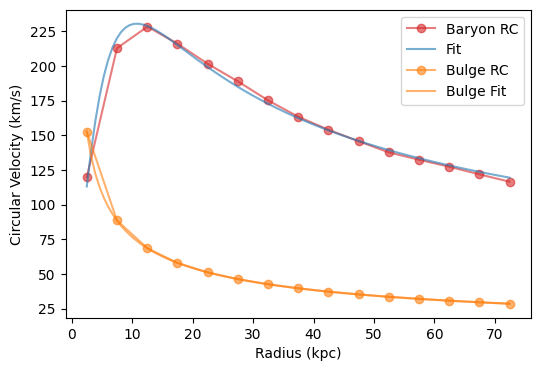

In [10]:
galaxy = dgbrc

# fit to the disk + gas galaxy 
upsilon_d, _ = Gamma_disk(galaxy)
upsilon_b, _ = Gamma_bulge(galaxy)
fitter = KuzminFit(galaxy, gamma_star=upsilon_d, gamma_bulge=upsilon_b, method='lmfit')

# data 
df, _, _ = get_rc_data(galaxy)

radii = fitter.r_vals
baryon_rc = fitter.vc_disk_gas
bulge_rc = fitter.vc_bulge
r_list = np.linspace(radii.min(), radii.max(), 100)

Mb = fitter.M_b_fit
a = fitter.a_fit
vc_fit = kuzmin_model(r_list, log_M_b=np.log10(Mb), log_a=np.log10(a))

Mb_bulge = fitter.M_b_fit_bulge
a_bulge = fitter.a_fit_bulge
vc_fit_bulge = hernquist_model(r_list, log_M_b=np.log10(Mb_bulge), log_a=np.log10(a_bulge))


# plot the results
plt.figure(figsize=(6,4))
plt.plot(radii, baryon_rc, marker='o', linestyle='-', alpha=0.6, color='C3', label='Baryon RC')
plt.plot(r_list, vc_fit, marker='None', linestyle='-', alpha=0.6, color='C0', label='Fit')
plt.plot(radii, bulge_rc, marker='o', linestyle='-', alpha=0.6, color='C1', label='Bulge RC')
plt.plot(r_list, vc_fit_bulge, marker='None', linestyle='-', alpha=0.6, color='C1', label='Bulge Fit')
plt.xlabel('Radius (kpc)')
plt.ylabel('Circular Velocity (km/s)')
plt.legend()
plt.show()

# Generate fits for both 1D and 2D Models and Compare

In [22]:
# basic cuts to galaxy data 
subset = []
galaxies = get_galaxy_ids()
for g in galaxies:
    df, _, _ = get_rc_data(g)
    data, _ = get_mass_data(g)
    if len(df) >= 8:
        if data["Q"].values == 1 or data["Q"].values == 2:
            subset.append(g)
        else:
            print(f"Galaxy {g} has Q = {data['Q'].values}, skipping.")

Galaxy NGC2366 has Q = [3], skipping.
Galaxy NGC1705 has Q = [3], skipping.
Galaxy UGC04305 has Q = [3], skipping.
Galaxy UGC06973 has Q = [3], skipping.
Galaxy UGC02455 has Q = [3], skipping.


In [25]:
len(subset)

138

In [27]:
sph_results = []
nsph_results = []

labels = ["Galaxy", "M_b_fit", "a_fit", "chi2", "M_b_fit_bulge", "a_fit_bulge", "chi2_bulge"]

for g in subset:
    # Use the same M/L ratios for disk and bulge for both models
    gamma_d, _ = Gamma_disk(g)
    gamma_b, _ = Gamma_bulge(g)
    # 1D model: Hernquist for bulge and disk + gas 
    try:
        sfit = HernquistFit(g, gamma_star=gamma_d, gamma_bulge=gamma_b, method='lmfit')
        # disk + gas 
        sMbfit, safit = sfit.M_b_fit, sfit.a_fit
        schi2 = sfit.error
        # bulge (nans if no bulge)
        sMbfit_bulge, safit_bulge = sfit.M_b_fit_bulge, sfit.a_fit_bulge
        schi2_bulge = sfit.error_bulge
    except Exception as e:
        print(f"Error fitting Hernquist model to {g}: {e}")
        sMbfit, safit, schi2 = np.nan, np.nan, np.nan
        sMbfit_bulge, safit_bulge, schi2_bulge = np.nan, np.nan, np.nan
        continue  # Skip to the next galaxy if fitting fails

    sph_results.append([g, sMbfit, safit, schi2, sMbfit_bulge, safit_bulge, schi2_bulge]) 
    
    # 2D model: Kuzmin disk + gas, Hernquist for bulge
    try:
        nfit = KuzminFit(g, gamma_star=gamma_d, gamma_bulge=gamma_b, method='lmfit')
        # disk + gas 
        nMbfit, nafit = nfit.M_b_fit, nfit.a_fit
        nchi2 = nfit.error
        # bulge (nans if no bulge)
        nMbfit_bulge, nafit_bulge = nfit.M_b_fit_bulge, nfit.a_fit_bulge
        nchi2_bulge = nfit.error_bulge
    except Exception as e:
        print(f"Error fitting Kuzmin model to {g}: {e}")
        nMbfit, nafit, nchi2 = np.nan, np.nan, np.nan
        nMbfit_bulge, nafit_bulge, nchi2_bulge = np.nan, np.nan, np.nan
        continue  # Skip to the next galaxy if fitting fails

    nsph_results.append([g, nMbfit, nafit, nchi2, nMbfit_bulge, nafit_bulge, nchi2_bulge]) 
    
    
    # plotting
    r_vals = sfit.r_vals
    r_list = np.geomspace(r_vals.min(), r_vals.max(), 100)
    
    # data
    vc_dg = sfit.vc_disk_gas # same data for both models
    vc_b = sfit.vc_bulge # same data for both models
    
    # fits 
    # spherical model (Hernquist)
    svc_disk_fit = hernquist_model(r_list, log_M_b=np.log10(sMbfit), log_a=np.log10(safit))
    svc_bulge_fit = hernquist_model(r_list, log_M_b=np.log10(sMbfit_bulge), log_a=np.log10(safit_bulge))
    # Kuzmin + Hernquist model
    nvc_disk_fit = kuzmin_model(r_list, log_M_b=np.log10(nMbfit), log_a=np.log10(nafit))
    nvc_bulge_fit = hernquist_model(r_list, log_M_b=np.log10(nMbfit_bulge), log_a=np.log10(nafit_bulge))
    
    plt.figure(figsize=(6,4))
    plt.plot(r_vals, vc_dg, marker='o', linestyle=None, alpha=0.6, color='k', label='Disk + Gas data')
    plt.plot(r_vals, vc_b, marker='o', linestyle=None, alpha=0.6, color='grey', label='Bulge data')
    # spherical model fits 
    plt.plot(r_list, svc_disk_fit, marker=None, linestyle='-', alpha=0.6, color='C0', label='Hernquist Disk + Gas Fit')
    plt.plot(r_list, svc_bulge_fit, marker=None, linestyle='--', alpha=0.6, color='C0', label='Hernquist Bulge Fit')
    # Kuzmin + Hernquist model fits
    plt.plot(r_list, nvc_disk_fit, marker=None, linestyle='-', alpha=0.6, color='C1', label='Kuzmin Disk + Gas Fit')
    plt.plot(r_list, nvc_bulge_fit, marker=None, linestyle='--', alpha=0.6, color='C1', label='Hernquist Bulge Fit')
    plt.xlabel('Radius [kpc]')
    plt.ylabel('Circular Velocity [km/s]')
    plt.title(f'Galaxy: {g} Comparison of Hernquist and Kuzmin Fits')
    plt.legend()
    plt.savefig(f'../plots/fits/compare/{g}_hernquist_kuzmin_fit.png', dpi=300)
    plt.close()
    
sresults_df = pd.DataFrame(sph_results, columns=labels)
sresults_df.to_csv('../data/hernquist_fit_results.csv', index=False)
nresults_df = pd.DataFrame(nsph_results, columns=labels)
nresults_df.to_csv('../data/kuzmin_fit_results.csv', index=False)
    

Fitting with lmfit took 0.0093 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 3.38e+11 solar masses
  a   = 10.72 kpc
  chi-squared = 5220.8497
Fitting with lmfit took 0.0125 seconds
Fitted parameters for galaxy NGC5371 using lmfit:
  M_b = 1.89e+11 solar masses
  a   = 7.50 kpc
  chi-squared = 14834.1797
Fitting with lmfit took 0.0185 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 4.09e+11 solar masses
  a   = 100.00 kpc
  chi-squared = 218.9158
Fitting with lmfit took 0.0152 seconds
Fitted parameters for galaxy UGC05829 using lmfit:
  M_b = 3.85e+10 solar masses
  a   = 15.97 kpc
  chi-squared = 17.8969
Fitting with lmfit took 0.0131 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 3.04e+11 solar masses
  a   = 7.39 kpc
  chi-squared = 1667.2293
Bulge component detected, performing separate fit for bulge...
Fitting with lmfit took 0.0157 seconds
Fitted parameters for galaxy NGC5005 using lmfit:
  M_b = 1.50e+10 solar masses
  a 

In [35]:
sdf = pd.read_csv('../data/hernquist_fit_results.csv')
ndf = pd.read_csv('../data/kuzmin_fit_results.csv')

sdg_chi2 = sdf["chi2"].values
ndg_chi2 = ndf["chi2"].values

sb_chi2 = sdf["chi2_bulge"].values
nb_chi2 = ndf["chi2_bulge"].values

# count the chi2 values that are smaller for ndg than sdg
better_ndg = np.sum(ndg_chi2 < sdg_chi2)
print(f"Number of galaxies where Kuzmin disk + gas has smaller chi2 than Hernquist disk + gas: {better_ndg} out of {len(sdf)}")

# count the chi2 values that are smaller for nb than sb
better_nb = np.sum(nb_chi2 == sb_chi2)
print(f"Number of galaxies where Hernquist bulge has smaller chi2 than Kuzmin bulge: {better_nb} out of {len(sdf)}")

# plt.figure(figsize=(16,4))
# plt.scatter(sdf["Galaxy"], sdg_chi2, marker='o', color='C0', label='Hernquist Disk + Gas')
# plt.scatter(ndf["Galaxy"], ndg_chi2, marker='o', color='C1', label='Kuzmin Disk + Gas')
# # rotate x-axis labels for better readability
# plt.xticks(rotation=90, ha='right')
# plt.xlabel('Galaxy')
# plt.ylim(0,100)
# plt.legend()
# plt.tight_layout()
# plt.show()

Number of galaxies where Kuzmin disk + gas has smaller chi2 than Hernquist disk + gas: 71 out of 138
Number of galaxies where Hernquist bulge has smaller chi2 than Kuzmin bulge: 30 out of 138


# Check the potentials 

In [19]:
G = 4.30091e-6  # [kpc * (km/s)^2 / solar mass]

def hernquist_potential(Mb=1e10, a=1):
    """
    Calculate the Hernquist potential for given mass and scale length.
    Returns a spherical potential function that can be evaluated at any radius r with ghost variable theta.
    """
    def func(r, th):
        return - G * Mb / (r + a)
        
    return func

def kuzmin_potential(Mb=1e10, a=1):
    """
    Calculate the Kuzmin potential for given mass and scale length.
    Returns a potential function that can be evaluated at any position (R, z).
    """
    def func(r, th):
        R = r * np.sin(th)
        z = r * np.cos(th)
        return - (G * Mb) / np.sqrt(R**2 + (a + np.abs(z))**2)
        
    return func

def kuzmin_potential_cyl(Mb=1e10, a=1):
    """
    Calculate the Kuzmin potential for given mass and scale length.
    Returns a potential function that can be evaluated at any position (R, z).
    """
    def func(R, z):
        return - (G * Mb) / np.sqrt(R**2 + (a + np.abs(z))**2)
        
    return func

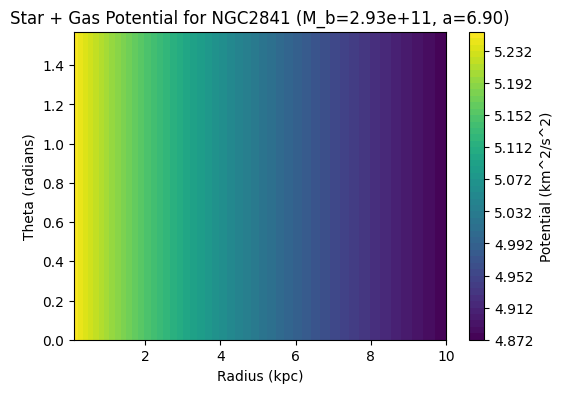

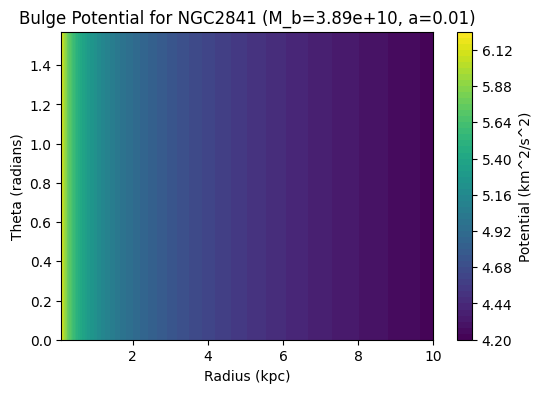

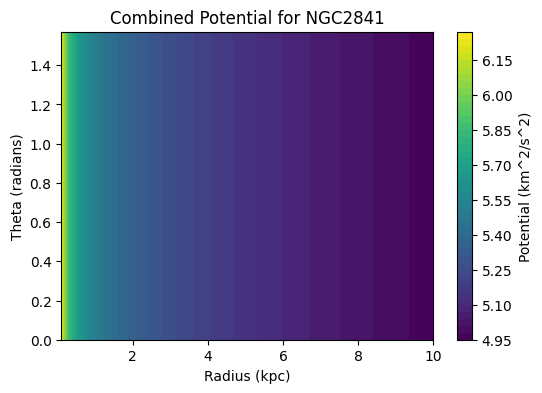

In [20]:
gal = "NGC2841"

sdf = pd.read_csv('../data/hernquist_fit_results.csv')
ndf = pd.read_csv('../data/kuzmin_fit_results.csv')

sMb, sa = sdf[sdf["Galaxy"] == gal][["M_b_fit", "a_fit"]].values[0]
sMb_bulge, sa_bulge = sdf[sdf["Galaxy"] == gal][["M_b_fit_bulge", "a_fit_bulge"]].values[0]

nMb, na = ndf[ndf["Galaxy"] == gal][["M_b_fit", "a_fit"]].values[0]
nMb_bulge, na_bulge = ndf[ndf["Galaxy"] == gal][["M_b_fit_bulge", "a_fit_bulge"]].values[0]


r_list = np.linspace(0.1, 10, 100)
z_list = np.linspace(-10, 10, 100)
thetas = np.linspace(0, np.pi/2, 100)

# create array to plot heatmap 
s_potential = hernquist_potential(Mb=sMb, a=sa)
n_potential = kuzmin_potential(Mb=nMb, a=na)

sb_potential = hernquist_potential(Mb=sMb_bulge, a=sa_bulge)
nb_potential = kuzmin_potential(Mb=nMb_bulge, a=na_bulge)

# spherical potential plot 
rs, ths = np.meshgrid(r_list, thetas)
s_phi = s_potential(rs, ths)
s_phi_bulge = sb_potential(rs, ths)

plt.figure(figsize=(6,4))
plt.contourf(rs, ths, np.log10(np.abs(s_phi)), levels=50, cmap='viridis')
plt.colorbar(label='Potential (km^2/s^2)')
plt.xlabel('Radius (kpc)')
plt.ylabel('Theta (radians)')
plt.title(f'Star + Gas Potential for {gal} (M_b={sMb:.2e}, a={sa:.2f})')
plt.show()
plt.close()

plt.figure(figsize=(6,4))
plt.contourf(rs, ths, np.log10(np.abs(s_phi_bulge)), levels=50, cmap='viridis')
plt.colorbar(label='Potential (km^2/s^2)')
plt.xlabel('Radius (kpc)')
plt.ylabel('Theta (radians)')
plt.title(f'Bulge Potential for {gal} (M_b={sMb_bulge:.2e}, a={sa_bulge:.2f})')
plt.show()
plt.close()

phi_combined = s_phi + s_phi_bulge
plt.figure(figsize=(6,4))
plt.contourf(rs, ths, np.log10(np.abs(phi_combined)), levels=50, cmap='viridis')
plt.colorbar(label='Potential (km^2/s^2)')
plt.xlabel('Radius (kpc)')
plt.ylabel('Theta (radians)')
plt.title(f'Combined Potential for {gal}')
plt.show()
plt.close()

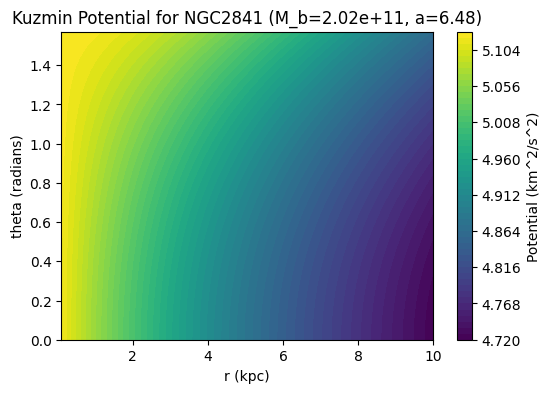

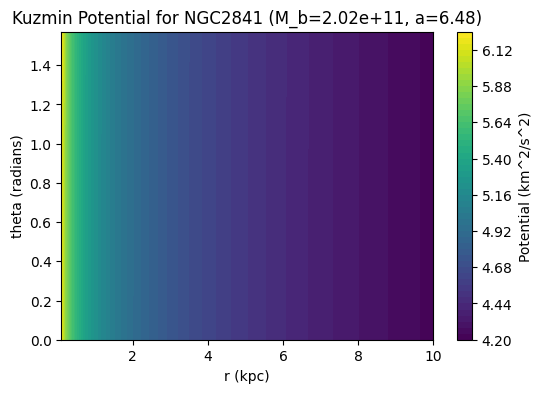

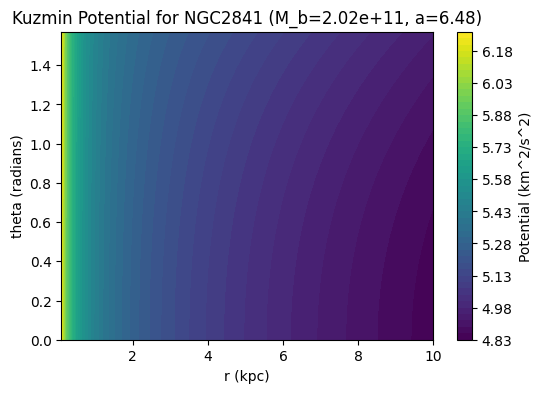

In [21]:
# nonspherical potential plot
rs, ths = np.meshgrid(r_list, thetas)
n_phi = n_potential(rs, ths)
n_phi_bulge = nb_potential(rs, ths)

plt.figure(figsize=(6,4))
plt.contourf(rs, ths, np.log10(np.abs(n_phi)), levels=50, cmap='viridis')
plt.colorbar(label='Potential (km^2/s^2)')
plt.xlabel('r (kpc)')
plt.ylabel('theta (radians)')
plt.title(f'Kuzmin Potential for {gal} (M_b={nMb:.2e}, a={na:.2f})')
plt.show()
plt.close()

plt.figure(figsize=(6,4))
plt.contourf(rs, ths, np.log10(np.abs(n_phi_bulge)), levels=50, cmap='viridis')
plt.colorbar(label='Potential (km^2/s^2)')
plt.xlabel('r (kpc)')
plt.ylabel('theta (radians)')
plt.title(f'Kuzmin Potential for {gal} (M_b={nMb:.2e}, a={na:.2f})')
plt.show()
plt.close()

n_combined_phi = n_phi + n_phi_bulge

plt.figure(figsize=(6,4))
plt.contourf(rs, ths, np.log10(np.abs(n_combined_phi)), levels=50, cmap='viridis')
plt.colorbar(label='Potential (km^2/s^2)')
plt.xlabel('r (kpc)')
plt.ylabel('theta (radians)')
plt.title(f'Kuzmin Potential for {gal} (M_b={nMb:.2e}, a={na:.2f})')
plt.show()
plt.close()

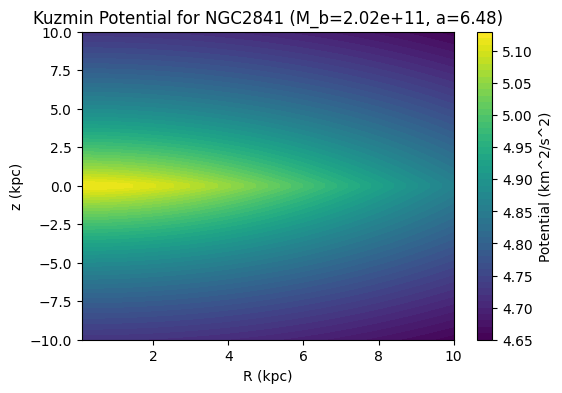

In [22]:
# nonspherical potential plot
Rs, zs = np.meshgrid(r_list, z_list)

n_potential_cyl = kuzmin_potential_cyl(Mb=nMb, a=na)

n_phi_cyl = n_potential_cyl(Rs, zs)
# n_phi_bulge = nb_potential_cyl(Rs, zs)

plt.figure(figsize=(6,4))
plt.contourf(Rs, zs, np.log10(np.abs(n_phi_cyl)), levels=50, cmap='viridis')
plt.colorbar(label='Potential (km^2/s^2)')
plt.xlabel('R (kpc)')
plt.ylabel('z (kpc)')
plt.title(f'Kuzmin Potential for {gal} (M_b={nMb:.2e}, a={na:.2f})')
plt.show()
plt.close()

# Surface Brightness Approach